In [38]:
import kagglehub
path = kagglehub.dataset_download("aslanahmedov/walmart-sales-forecast")

In [39]:
!pip install kagglehub

In [40]:
!pip install prophet

import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [19]:
import kagglehub
path = kagglehub.dataset_download("aslanahmedov/walmart-sales-forecast")

In [20]:
df = pd.read_csv(f"{path}/train.csv")

print(df.head())
print(df.columns)

   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False
Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'], dtype='str')


In [21]:
df = df[['Date', 'Weekly_Sales']].copy()

# Group all sales by date
df = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

# Rename columns
df.rename(columns={
    'Date': 'ds',
    'Weekly_Sales': 'y'
}, inplace=True)

# Convert date format
df['ds'] = pd.to_datetime(df['ds'])

# Sort by date
df = df.sort_values('ds')

In [22]:
print(df.isnull().sum())
df = df.dropna()

ds    0
y     0
dtype: int64


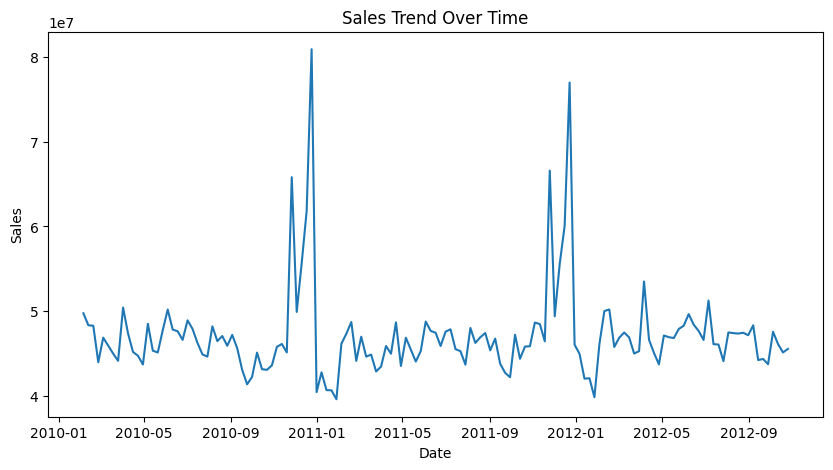

In [23]:
plt.figure(figsize=(10,5))
plt.plot(df['ds'], df['y'])
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

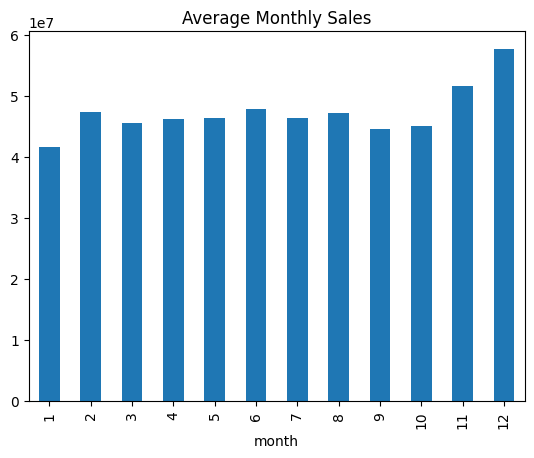

In [42]:
df['month'] = df['ds'].dt.month
df.groupby('month')['y'].mean().plot(kind='bar')
plt.title("Average Monthly Sales")
plt.show()

In [43]:
model = Prophet()
model.fit(df)

13:43:45 - cmdstanpy - INFO - Chain [1] start processing
13:43:45 - cmdstanpy - INFO - Chain [1] done processing


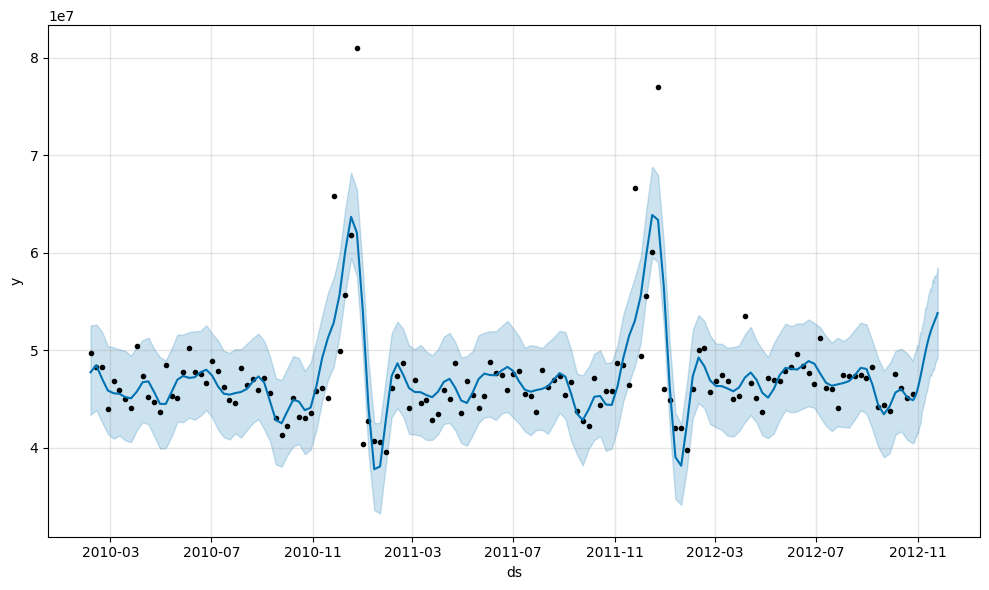

In [44]:
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

model.plot(forecast)
plt.show()

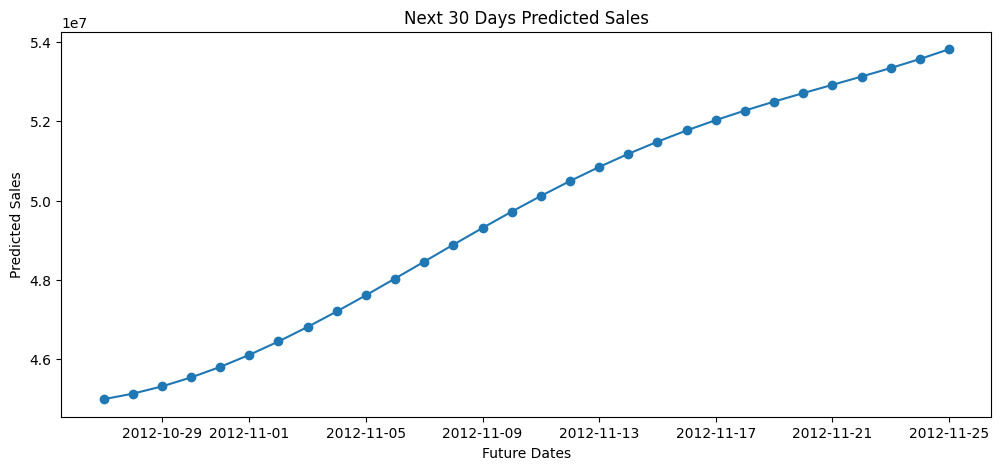

In [45]:
# Future 30 Days Forecast Only

future_only = forecast.tail(30)

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(
    future_only['ds'],
    future_only['yhat'],
    marker='o'
)

ax.set_title("Next 30 Days Predicted Sales")

ax.set_xlabel("Future Dates")

ax.set_ylabel("Predicted Sales")

plt.show()

In [46]:
# Use last 30 days for testing
train = df[:-30]
test = df[-30:]

model = Prophet()
model.fit(train)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

pred = forecast.tail(30)['yhat'].values
actual = test['y'].values

mae = mean_absolute_error(actual, pred)
rmse = np.sqrt(mean_squared_error(actual, pred))

print("MAE:", mae)
print("RMSE:", rmse)

13:44:28 - cmdstanpy - INFO - Chain [1] start processing
13:44:28 - cmdstanpy - INFO - Chain [1] done processing


MAE: 1534876.4958027757
RMSE: 2187901.9129551277


In [47]:
print("Forecast completed successfully")

Forecast completed successfully


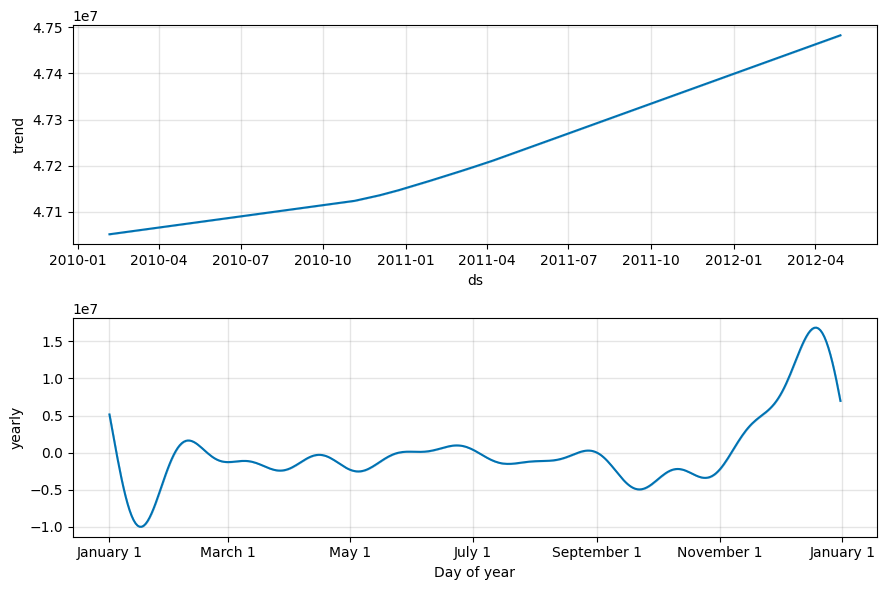

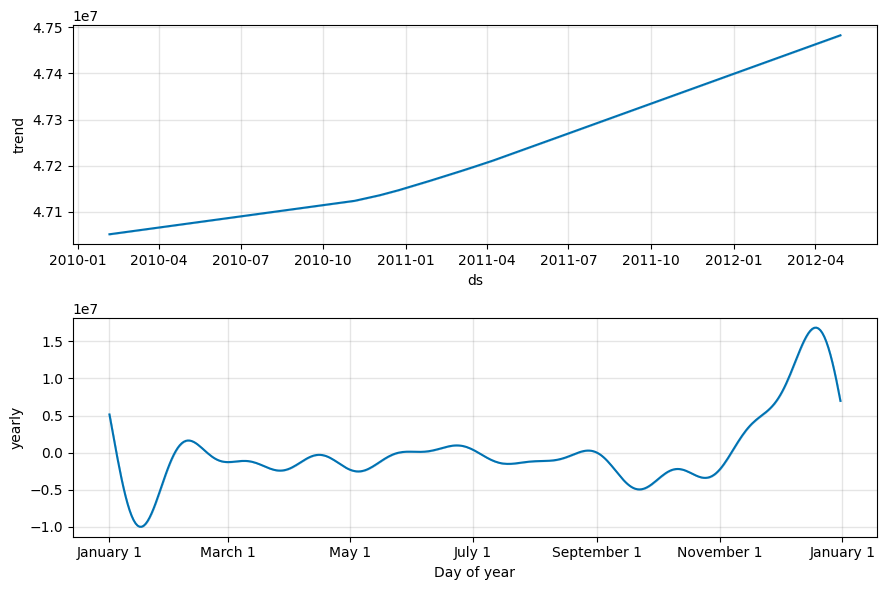

In [48]:
model.plot_components(forecast)

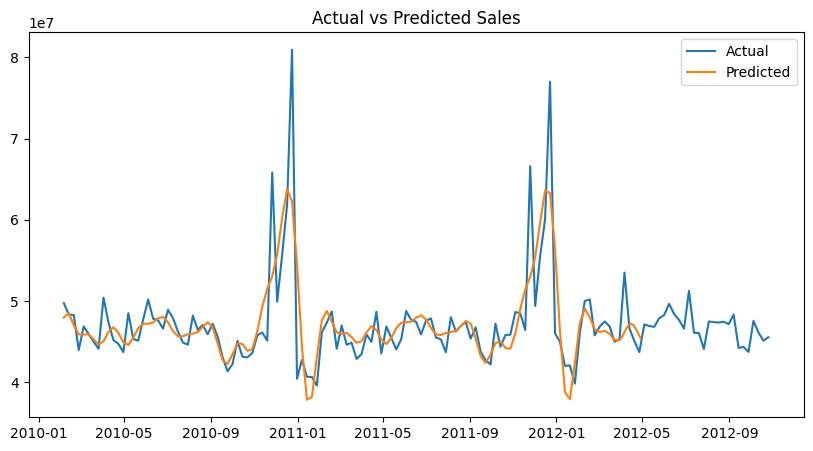

In [49]:
plt.figure(figsize=(10,5))
plt.plot(df['ds'], df['y'], label='Actual')
plt.plot(forecast['ds'], forecast['yhat'], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()